In [1]:
import numpy as np
import matplotlib.pyplot as plt
from forTP1 import Bandit

myBandit = Bandit()

#### Uniform Exploration

In [14]:
K = 4
T = 500
bandits = [[0]]
for k in range(K-1):
    bandits.append([0]) 

print(bandits)

for t in range(T):
    k = np.random.randint(0,K)
    reward = myBandit.get_arm(k)
    # print(k,reward)
    bandits[k] += reward

print(bandits)

print(np.argmax(bandits))

[[0], [0], [0], [0]]
[array([1638]), array([1653]), array([944]), array([881])]
1


In [52]:
def Uniform_Exploration(K, T, N, plot=False):
    bandits = [[]]
    for k in range(K-1):
        bandits.append([]) 

    for n in range(N):
        for k in range(K):
            # k = np.random.randint(0,K)
            reward = myBandit.get_arm(k)
            bandits[k].append(reward)

    summs = [sum(sub_array) for sub_array in bandits]
    bestk = np.argmax(summs)

    for t in range(T-(K*N)):
        reward = myBandit.get_arm(bestk)
        bandits[k].append(reward)

    summs = [sum(sub_array) for sub_array in bandits]

    if plot == True:
        fig = plt.figure()
        plt.violinplot(bandits)
        plt.show()

    return np.sum(summs)/T

    

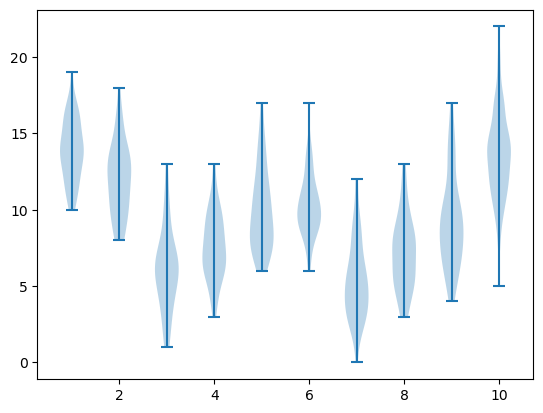

In [62]:
K = 10
T = 1000
N = 50
reward = Uniform_Exploration(K, T, N, True)

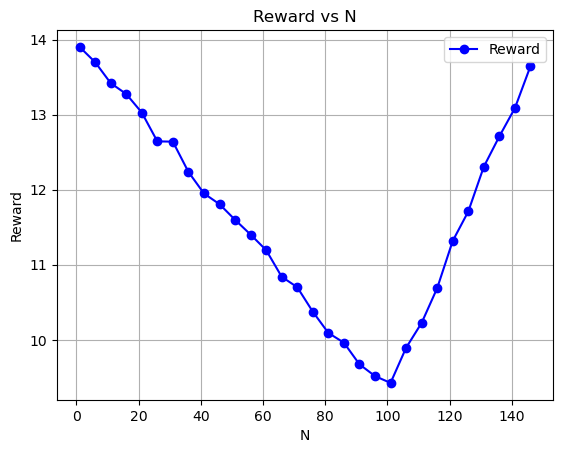

In [75]:
N_values = range(1, 151, 5)
reward_values = []

for N in N_values:
    reward = Uniform_Exploration(K, T, N)  
    reward_values.append(reward)  

plt.plot(N_values, reward_values, marker='o', linestyle='-', color='b', label='Reward')
plt.xlabel('N')
plt.ylabel('Reward')
plt.title('Reward vs N')
plt.legend()
plt.grid(True)
plt.show()

#### ε-Greedy

In [71]:
def Ep_Greedy(K, T, Epsilon, plot = False):
    bandits = [[]]
    for k in range(K-1):
        bandits.append([]) 

    k = np.random.randint(0,K)

    for t in range(T):

        if np.random.uniform(0, 1) > Epsilon:
            meds = [np.average(sub_array) for sub_array in bandits]
            k = np.argmax(meds)
            
        else:
            k = np.random.randint(0,K)
        
        reward = myBandit.get_arm(k)
        bandits[k].append(reward)

    summs = [sum(sub_array) for sub_array in bandits]

    if plot == True:
        fig = plt.figure()
        plt.violinplot(bandits)
        plt.show()

    return np.sum(summs)/T

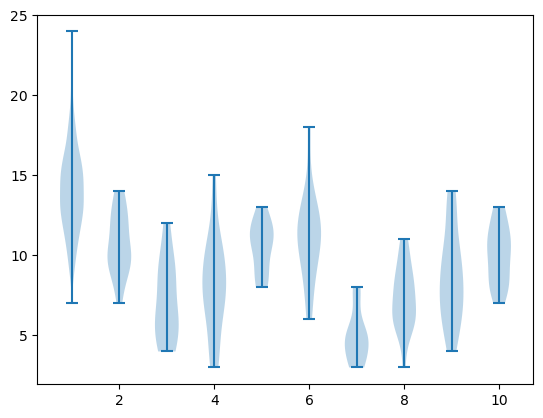

In [72]:
Epsilon = 0.2
reward = Ep_Greedy(K, T, Epsilon, True)

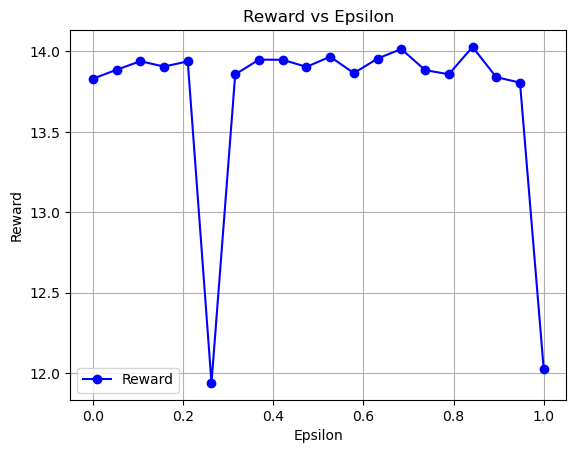

In [83]:
Ep_values = np.linspace(0, 1, 20)
reward_values = []

for ep in Ep_values:
    reward = Ep_Greedy(K, T, ep/100)  
    reward_values.append(reward)  

plt.plot(Ep_values, reward_values, marker='o', linestyle='-', color='b', label='Reward')
plt.xlabel('Epsilon')
plt.ylabel('Reward')
plt.title('Reward vs Epsilon')
plt.legend()
plt.grid(True)
plt.show()